# Evaluate and Summarize Experiment Results

This notebook aggregates experiment metrics, exports summary tables, and generates ablation figures.

## Cell layout
- **Cell 1**: imports and project-root setup
- **Cell 2**: all tunable runtime parameters
- **Cell 3**: Step 2 plotting parameters
- **Remaining steps**: helper functions and function calls are separated into different cells

## Preferred `true_only` layout
`true_only` is treated as a fixed baseline:
- it does **not** participate in regular noise sweeps,
- each environment is evaluated once per seed,
- the preferred layout is `results/raw_metrics/true_only/<env>/seed_<seed>/metrics.json`.

Legacy results stored under `results/true_only/<env>/seed1/` are optional and only used when `INCLUDE_LEGACY_TRUE_ONLY = True`.


In [22]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    """Locate the project root by searching upward for `src/` and `results/`."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate the project root containing both 'src/' and 'results/'.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR, RAW_METRICS_DIR, TABLES_DIR  # noqa: E402

LEGACY_RESULTS_DIR = PROJECT_ROOT / "results"
print(f"[INFO] PROJECT_ROOT = {PROJECT_ROOT}")
print(f"[INFO] RAW_METRICS_DIR = {RAW_METRICS_DIR}")
print(f"[INFO] LEGACY_RESULTS_DIR = {LEGACY_RESULTS_DIR}")


[INFO] PROJECT_ROOT = /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement
[INFO] RAW_METRICS_DIR = /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/raw_metrics
[INFO] LEGACY_RESULTS_DIR = /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results


In [23]:
# Tunable runtime parameters
TARGET_METHODS = [
    "true_only",
    "plain",
    "raw_noisy",
    "disentangled_cov",
    "disentangled_hsic",
    "disentangled_barlow",
    "disentangled_dcor",
    "disentangled_infonce",
    "disentangled_l1",
]

TARGET_DIMS = [5, 10, 20, 40, 80]
TARGET_SCALES = [0.5, 1.0, 2.0, 4.0, 8.0]
TARGET_TYPES = ["nonlinear"]
TARGET_SEEDS = [1]

SAVE_FIGURES = True
SAVE_TABLES = True
SHOW_FIGURES = True

INCLUDE_LEGACY_TRUE_ONLY = False
TARGET_ENVS = [
    "halfcheetah-medium-v2",
    "hopper-medium-v2",
    "walker2d-medium-v2",
]

In [24]:
method_labels = {
    "true_only": "No Noise",
    "plain": "Plain Encoder",
    "raw_noisy": "Raw Noisy",
    "disentangled_cov": "Covariance",
    "disentangled_hsic": "HSIC",
    "disentangled_barlow": "Barlow",
    "disentangled_dcor": "dCor",
    "disentangled_infonce": "InfoNCE",
    "disentangled_l1": "L1",
}

global_order = [
    "No Noise",
    "Covariance",
    "HSIC",
    "Barlow",
    "dCor",
    "InfoNCE",
    "L1",
    "Plain Encoder",
    "Raw Noisy",
]

palette = {
    "No Noise": "#2c3e50",
    "Covariance": "#e74c3c",
    "HSIC": "#d35400",
    "Barlow": "#f39c12",
    "dCor": "#8e44ad",
    "InfoNCE": "#e84393",
    "L1": "#00cec9",
    "Plain Encoder": "#3498db",
    "Raw Noisy": "#bdc3c7",
}

sns.set_theme(style="whitegrid", font_scale=1.1)

## Step 1 — Collect evaluation records

In [25]:
def scale_to_tag(value: float) -> str:
    """Convert a float to a filename-safe tag, e.g. 0.5 -> 0p5."""
    return str(value).replace(".", "p")


def infer_method_from_path(path_str: str, target_methods) -> str:
    """Infer the method name from the directory path."""
    norm = path_str.replace("\\", "/")
    for method in target_methods:
        if f"/{method}/" in norm:
            return method
    return ""


def infer_env_from_path(path: Path, target_envs) -> str:
    """Infer the environment name from the path if it is not stored in the JSON payload."""
    path_parts = set(path.parts)
    for env_name in target_envs:
        if env_name in path_parts:
            return env_name
    return ""


def collect_eval_records(
    raw_metrics_dir: Path,
    legacy_results_dir: Path,
    target_methods,
    target_dims,
    target_scales,
    target_types,
    target_seeds,
    target_envs,
    include_legacy_true_only: bool = False,
):
    """Collect evaluation metrics from the new layout and, optionally, the legacy `true_only` layout."""
    records = []
    oracle_records = []
    visited_files = set()

    search_roots = [("new", raw_metrics_dir)]
    if include_legacy_true_only:
        search_roots.append(("legacy", legacy_results_dir / "true_only"))

    for layout_name, root in search_roots:
        if not root.exists():
            continue

        for file_path in root.rglob("*.json"):
            resolved = str(file_path.resolve())
            if resolved in visited_files:
                continue
            visited_files.add(resolved)

            try:
                with file_path.open("r", encoding="utf-8") as f:
                    data = json.load(f)
            except Exception:
                continue

            score = data.get("normalized_score")
            if score is None:
                continue

            path_norm = str(file_path.parent).replace("\\", "/")
            method = data.get("method") or data.get("group") or infer_method_from_path(path_norm, target_methods)
            if method not in target_methods:
                continue

            data_cfg = data.get("data_config", {})
            env_name = (
                data.get("env_name")
                or data.get("env")
                or data_cfg.get("env_name")
                or infer_env_from_path(file_path, target_envs)
            )

            seed = data.get("seed", data_cfg.get("seed"))
            if seed is None:
                match = re.search(r"seed_?(\d+)", path_norm, re.IGNORECASE)
                seed = int(match.group(1)) if match else None
            else:
                seed = int(seed)

            noise_dim = data.get("noise_dim", data_cfg.get("noise_dim"))
            noise_scale = data.get("noise_scale", data_cfg.get("noise_scale"))
            noise_type = data.get("noise_type", data_cfg.get("noise_type"))

            if method == "true_only":
                oracle_records.append(
                    {
                        "Method": "true_only",
                        "Env": env_name,
                        "Seed": seed,
                        "Score": float(score),
                        "Layout": layout_name,
                        "Source": str(file_path),
                    }
                )
                continue

            if noise_dim is None or noise_scale is None or noise_type is None:
                continue

            if noise_type not in target_types:
                continue
            if int(noise_dim) not in target_dims:
                continue
            if float(noise_scale) not in target_scales:
                continue
            if seed is None or int(seed) not in target_seeds:
                continue

            records.append(
                {
                    "Method": method,
                    "Env": env_name,
                    "Dim": int(noise_dim),
                    "Scale": float(noise_scale),
                    "Type": noise_type,
                    "Seed": int(seed),
                    "Score": float(score),
                    "Source": str(file_path),
                }
            )

    df_all = pd.DataFrame(records)
    oracle_df = pd.DataFrame(oracle_records)

    if not oracle_df.empty:
        oracle_df["LayoutPriority"] = oracle_df["Layout"].map({"new": 1, "legacy": 0}).fillna(0)
        oracle_df = (
            oracle_df.sort_values(["Env", "Seed", "LayoutPriority"], ascending=[True, True, False])
            .drop_duplicates(subset=["Env", "Seed"], keep="first")
            .drop(columns=["LayoutPriority"])
            .reset_index(drop=True)
        )

    oracle_mean = oracle_df["Score"].mean() if not oracle_df.empty else None
    return df_all, oracle_df, oracle_mean


In [26]:
df_all, oracle_df, oracle_mean = collect_eval_records(
    raw_metrics_dir=RAW_METRICS_DIR,
    legacy_results_dir=LEGACY_RESULTS_DIR,
    target_methods=TARGET_METHODS,
    target_dims=TARGET_DIMS,
    target_scales=TARGET_SCALES,
    target_types=TARGET_TYPES,
    target_seeds=TARGET_SEEDS,
    target_envs=TARGET_ENVS,
    include_legacy_true_only=INCLUDE_LEGACY_TRUE_ONLY,
)

target_type_str = TARGET_TYPES[0]
seed_tag = "_".join(str(s) for s in TARGET_SEEDS)

FIGURE_OUT_DIR = FIGURES_DIR / "ablations" / target_type_str
TABLE_OUT_DIR = TABLES_DIR / "ablations"
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Collected {len(df_all)} noise-sweep records.")
print(f"[INFO] Collected {len(oracle_df)} true_only baseline records.")
if oracle_mean is not None:
    print(f"[INFO] Oracle baseline mean score = {oracle_mean:.3f}")

df_all.head()

[INFO] Collected 201 noise-sweep records.
[INFO] Collected 1 true_only baseline records.
[INFO] Oracle baseline mean score = 40.724


,Method,Env,Dim,Scale,Type,Seed,Score,Source
0,raw_noisy,halfcheetah-medium-v2,20,2.0,nonlinear,1,10.670104,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...
1,disentangled_barlow,halfcheetah-medium-v2,10,0.5,nonlinear,1,39.763122,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...
2,disentangled_barlow,halfcheetah-medium-v2,10,1.0,nonlinear,1,37.822542,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...
3,disentangled_barlow,halfcheetah-medium-v2,10,2.0,nonlinear,1,32.091938,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...
4,disentangled_barlow,halfcheetah-medium-v2,10,4.0,nonlinear,1,5.132802,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...


## Step 2 — Plotting helpers

In [27]:
def plot_grouped_bars(sub_df, x_col, x_label, title, method_labels, global_order, palette, oracle_mean=None, save_path=None, show_figures=True):
    """Plot grouped bar charts and optionally save them to disk."""
    if sub_df.empty:
        return

    plot_df = sub_df.copy()

    if oracle_mean is not None:
        unique_x_vals = plot_df[x_col].unique()
        oracle_rows = [
            {"Method": "true_only", x_col: x_val, "Score": oracle_mean}
            for x_val in unique_x_vals
        ]
        plot_df = pd.concat([plot_df, pd.DataFrame(oracle_rows)], ignore_index=True)

    plot_df["Method Name"] = plot_df["Method"].map(method_labels)
    existing_methods = [m for m in global_order if m in plot_df["Method Name"].dropna().unique()]

    plot_df["Method Name"] = pd.Categorical(
        plot_df["Method Name"],
        categories=existing_methods,
        ordered=True,
    )
    plot_df = plot_df.sort_values([x_col, "Method Name"]).reset_index(drop=True)

    num_x_groups = len(plot_df[x_col].unique())
    num_methods = len(existing_methods)
    plt.figure(figsize=(max(8, num_x_groups * num_methods * 0.5), 6))

    ax = sns.barplot(
        data=plot_df,
        x=x_col,
        y="Score",
        hue="Method Name",
        palette=palette,
        edgecolor="black",
        linewidth=1.2,
        capsize=0.05,
    )

    for patch in ax.patches:
        height = patch.get_height()
        if pd.notna(height) and height > 0:
            ax.annotate(
                f"{height:.1f}",
                (patch.get_x() + patch.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                xytext=(0, 4),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
                rotation=90,
            )

    plt.title(title, fontsize=16, fontweight="bold", pad=15)
    plt.xlabel(x_label, fontsize=14, labelpad=10)
    plt.ylabel("Normalized D4RL Score", fontsize=14, labelpad=10)

    positive_scores = plot_df["Score"][plot_df["Score"] > 0]
    min_score = positive_scores.min() if not positive_scores.empty else 0
    max_score = plot_df["Score"].max()
    plt.ylim(max(0, min_score - 10), max_score + 15)

    plt.legend(
        title="Representation Method",
        title_fontsize=12,
        fontsize=10,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show_figures:
        plt.show()
    else:
        plt.close()

## Step 3 — Save summary tables

In [28]:
def build_summary_tables(df_all, oracle_df, method_labels):
    """Build export-ready summary tables for records and grouped statistics."""
    summary_df = pd.DataFrame()
    if not df_all.empty:
        summary_df = (
            df_all.groupby(["Method", "Env", "Dim", "Scale", "Type"], as_index=False)["Score"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        summary_df["Method Name"] = summary_df["Method"].map(method_labels)

    oracle_summary_df = pd.DataFrame()
    if not oracle_df.empty:
        oracle_summary_df = (
            oracle_df.groupby(["Method", "Env"], as_index=False)["Score"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        oracle_summary_df["Method Name"] = oracle_summary_df["Method"].map(method_labels)

    return summary_df, oracle_summary_df


def save_summary_tables(df_all, oracle_df, table_out_dir, target_type_str, seed_tag, method_labels):
    """Save filtered records and grouped summary tables to CSV files."""
    table_out_dir.mkdir(parents=True, exist_ok=True)

    summary_df, oracle_summary_df = build_summary_tables(df_all, oracle_df, method_labels)

    raw_csv_path = table_out_dir / f"filtered_records_{target_type_str}_seeds_{seed_tag}.csv"
    summary_csv_path = table_out_dir / f"summary_{target_type_str}_seeds_{seed_tag}.csv"
    oracle_csv_path = table_out_dir / "true_only_baseline_summary.csv"

    if not df_all.empty:
        df_all.to_csv(raw_csv_path, index=False)
        summary_df.to_csv(summary_csv_path, index=False)

    if not oracle_df.empty:
        oracle_df.to_csv(table_out_dir / "true_only_baseline_records.csv", index=False)
        oracle_summary_df.to_csv(oracle_csv_path, index=False)

    return {
        "raw_records": raw_csv_path if not df_all.empty else None,
        "summary": summary_csv_path if not summary_df.empty else None,
        "oracle_summary": oracle_csv_path if not oracle_summary_df.empty else None,
    }

In [29]:
if SAVE_TABLES:
    saved_tables = save_summary_tables(
        df_all=df_all,
        oracle_df=oracle_df,
        table_out_dir=TABLE_OUT_DIR,
        target_type_str=target_type_str,
        seed_tag=seed_tag,
        method_labels=method_labels,
    )
    for name, path in saved_tables.items():
        if path is not None:
            print(f"[INFO] Saved {name} table to: {path}")
else:
    print("[INFO] Table export is disabled.")

[INFO] Saved raw_records table to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/tables/ablations/filtered_records_nonlinear_seeds_1.csv
[INFO] Saved summary table to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/tables/ablations/summary_nonlinear_seeds_1.csv
[INFO] Saved oracle_summary table to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/tables/ablations/true_only_baseline_summary.csv


## Step 4 — Generate and save figures

In [30]:
def generate_ablation_charts(
    df_all,
    target_dims,
    target_scales,
    target_type_str,
    figure_out_dir,
    method_labels,
    global_order,
    palette,
    oracle_mean=None,
    save_figures=True,
    show_figures=True,
):
    """Generate scale-sweep and dimension-sweep ablation figures."""
    if df_all.empty:
        print(
            f"[ERROR] No valid evaluation data found for noise type '{target_type_str}' "
            "under the configured search paths."
        )
        return []

    saved_paths = []

    print(
        f"[INFO] Generating scale-sweep charts for noise type '{target_type_str}'..."
    )
    for dim in target_dims:
        df_sub = df_all[df_all["Dim"] == dim]
        if df_sub.empty:
            continue

        save_path = None
        if save_figures:
            save_path = figure_out_dir / f"scale_sweep_{target_type_str}_dim_{dim}.png"

        plot_grouped_bars(
            sub_df=df_sub,
            x_col="Scale",
            x_label=f"Noise Scale ({target_type_str.capitalize()})",
            title=f"Ablation on Noise Scale (Fixed Dim = {dim})",
            method_labels=method_labels,
            global_order=global_order,
            palette=palette,
            oracle_mean=oracle_mean,
            save_path=save_path,
            show_figures=show_figures,
        )
        if save_path is not None:
            saved_paths.append(save_path)

    print(
        f"[INFO] Generating dimension-sweep charts for noise type '{target_type_str}'..."
    )
    for scale in target_scales:
        df_sub = df_all[df_all["Scale"] == scale]
        if df_sub.empty:
            continue

        save_path = None
        if save_figures:
            scale_tag = scale_to_tag(scale)
            save_path = figure_out_dir / f"dim_sweep_{target_type_str}_scale_{scale_tag}.png"

        plot_grouped_bars(
            sub_df=df_sub,
            x_col="Dim",
            x_label=f"Noise Dimension ({target_type_str.capitalize()})",
            title=f"Ablation on Noise Dimension (Fixed Scale = {scale})",
            method_labels=method_labels,
            global_order=global_order,
            palette=palette,
            oracle_mean=oracle_mean,
            save_path=save_path,
            show_figures=show_figures,
        )
        if save_path is not None:
            saved_paths.append(save_path)

    return saved_paths

[INFO] Generating scale-sweep charts for noise type 'nonlinear'...


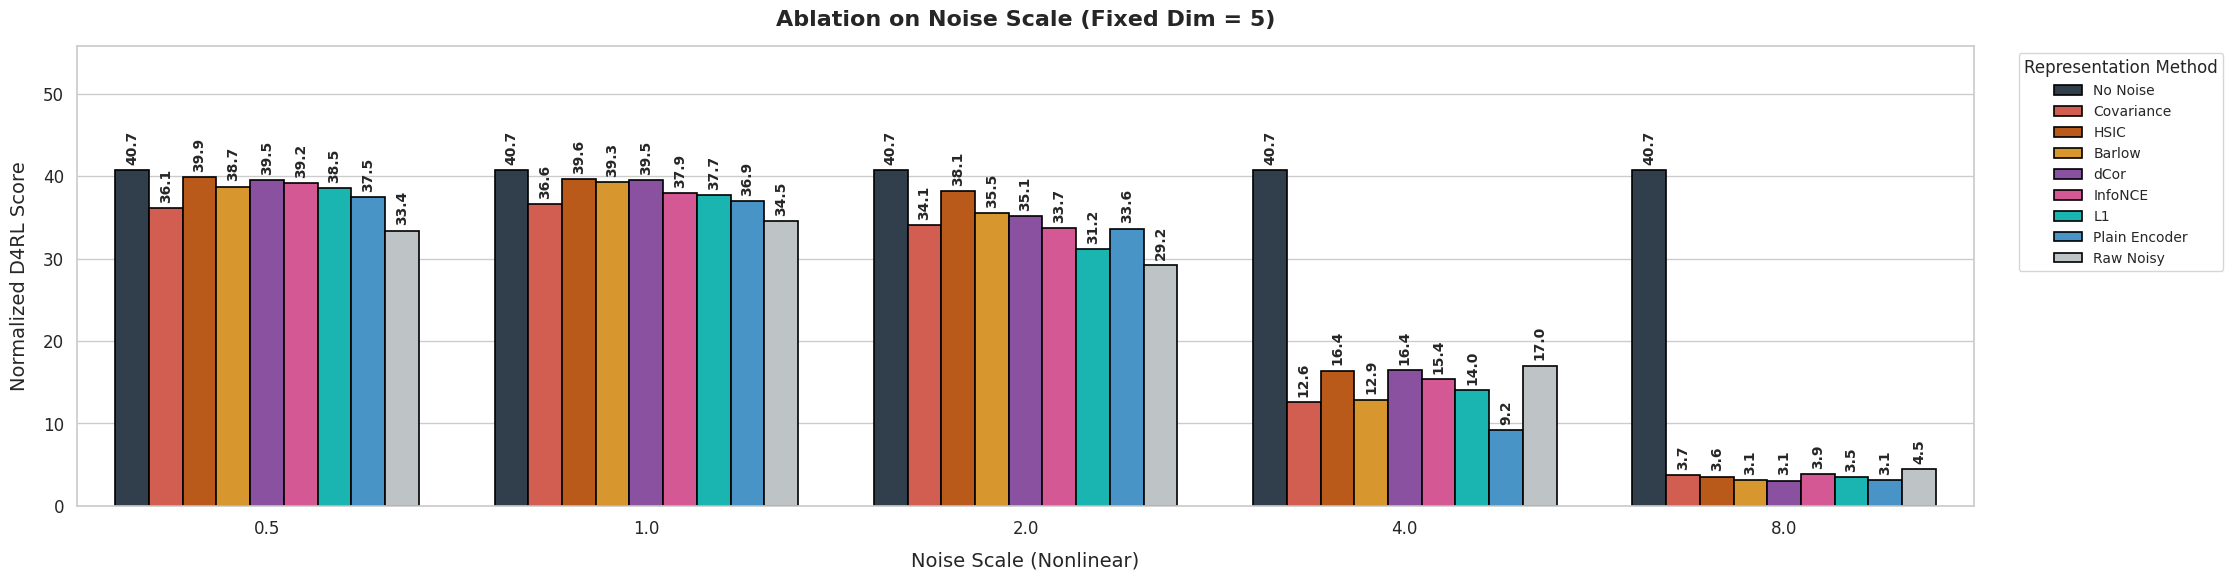

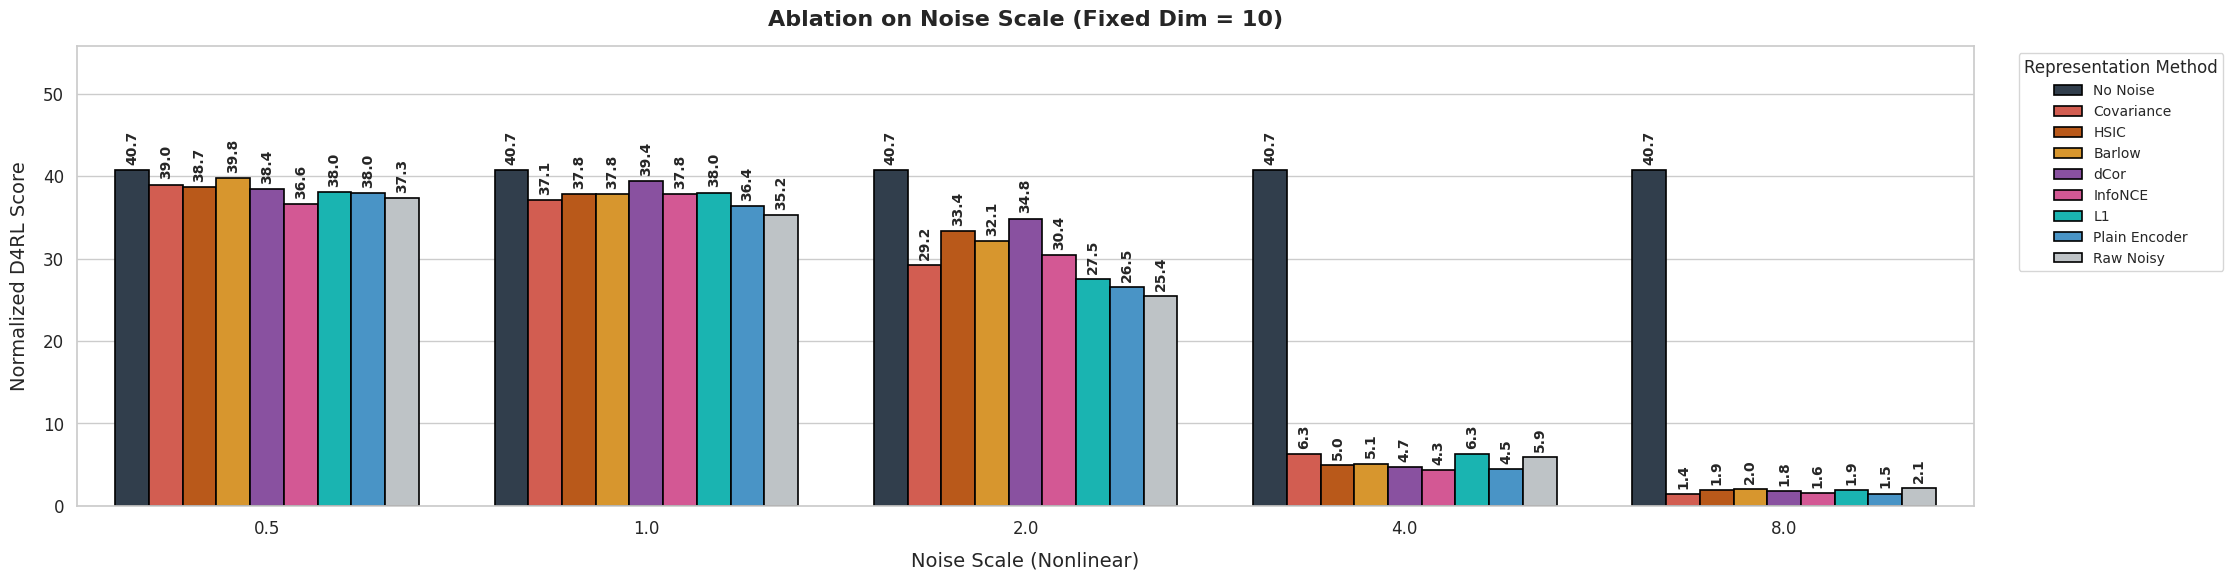

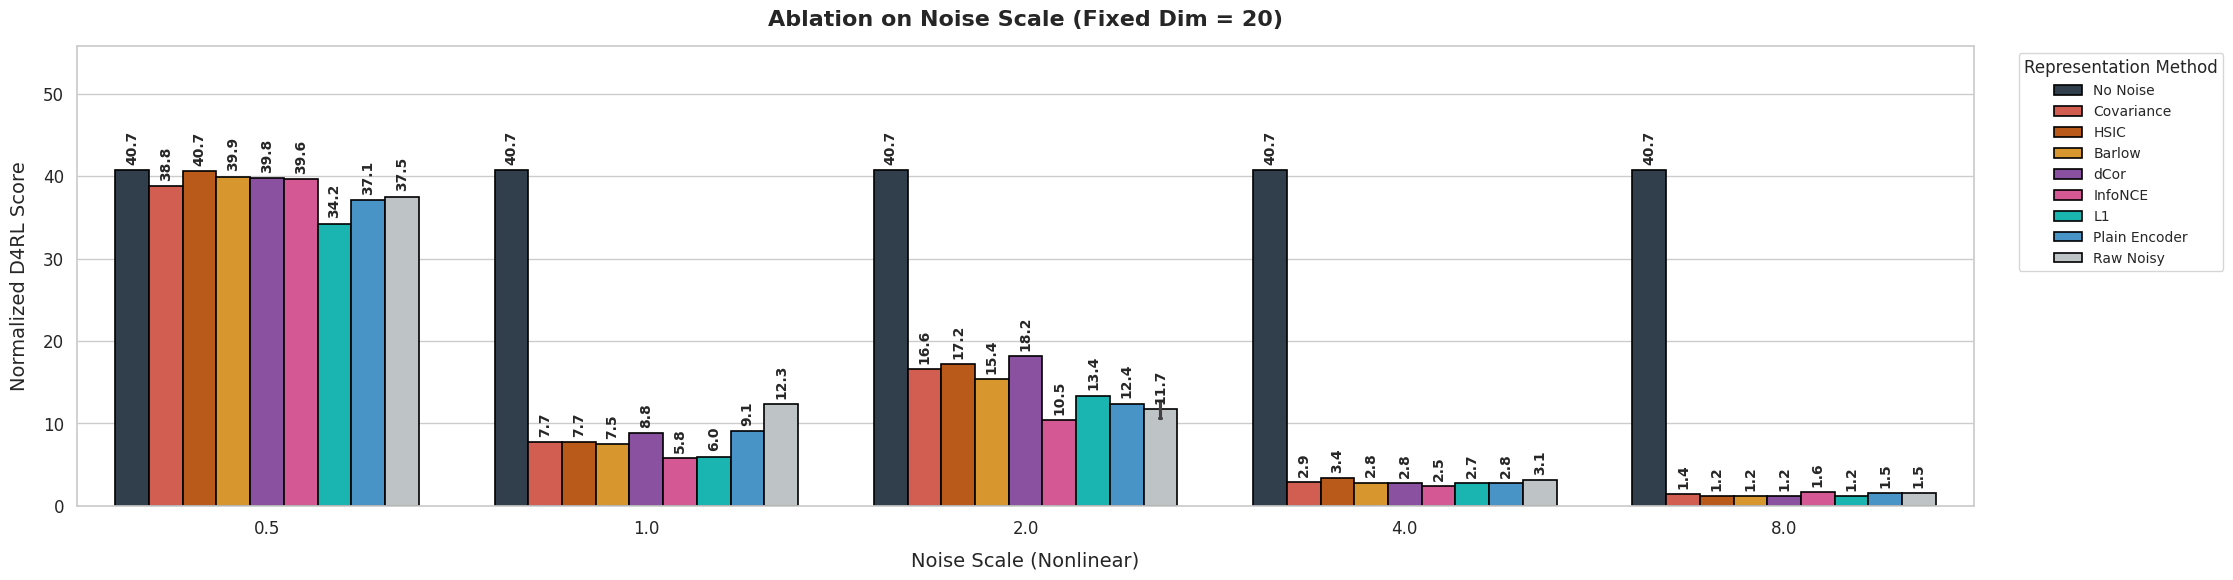

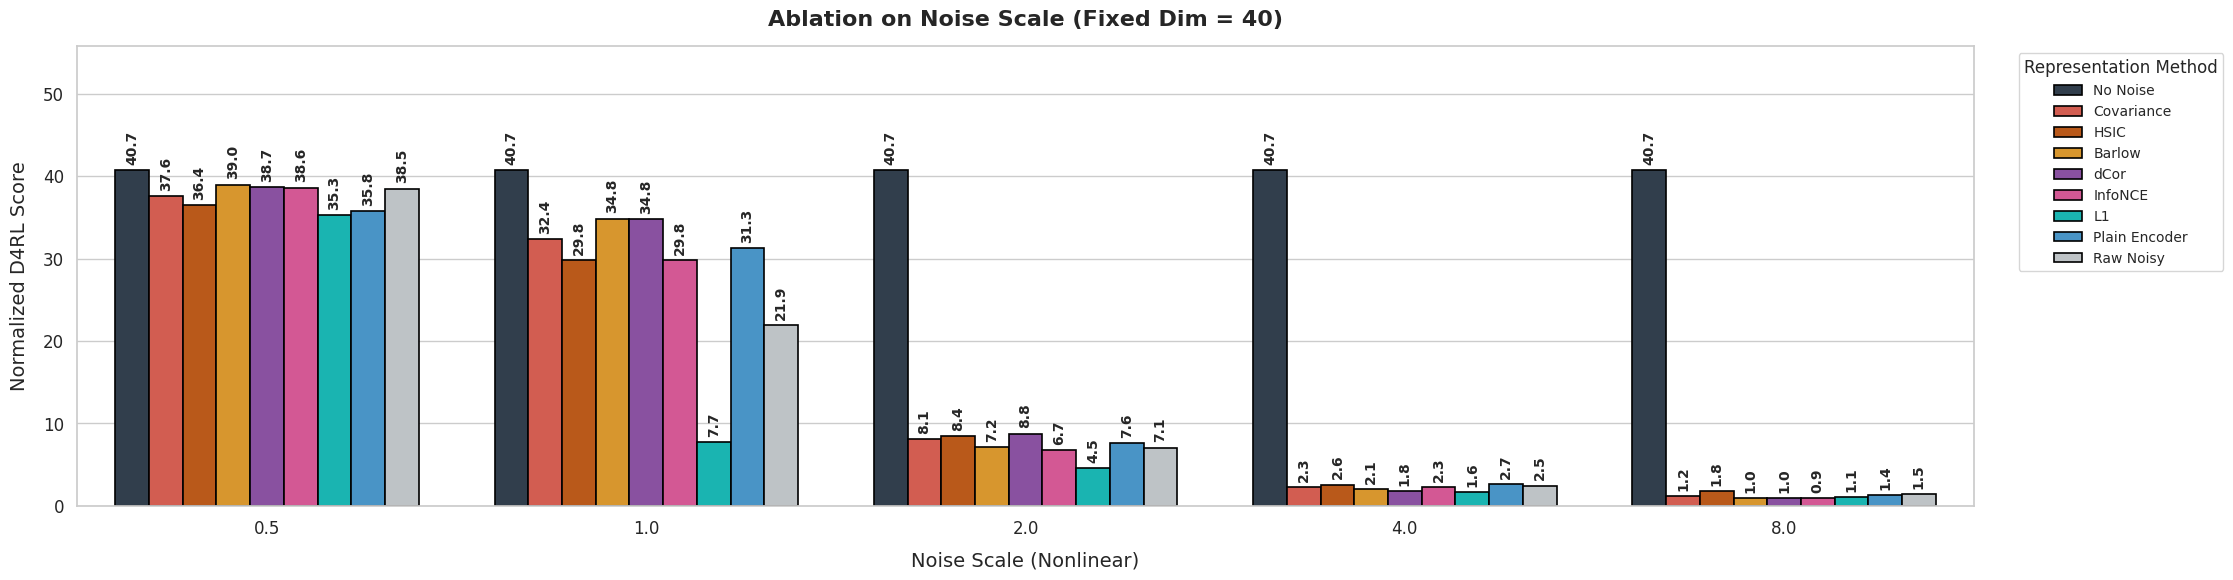

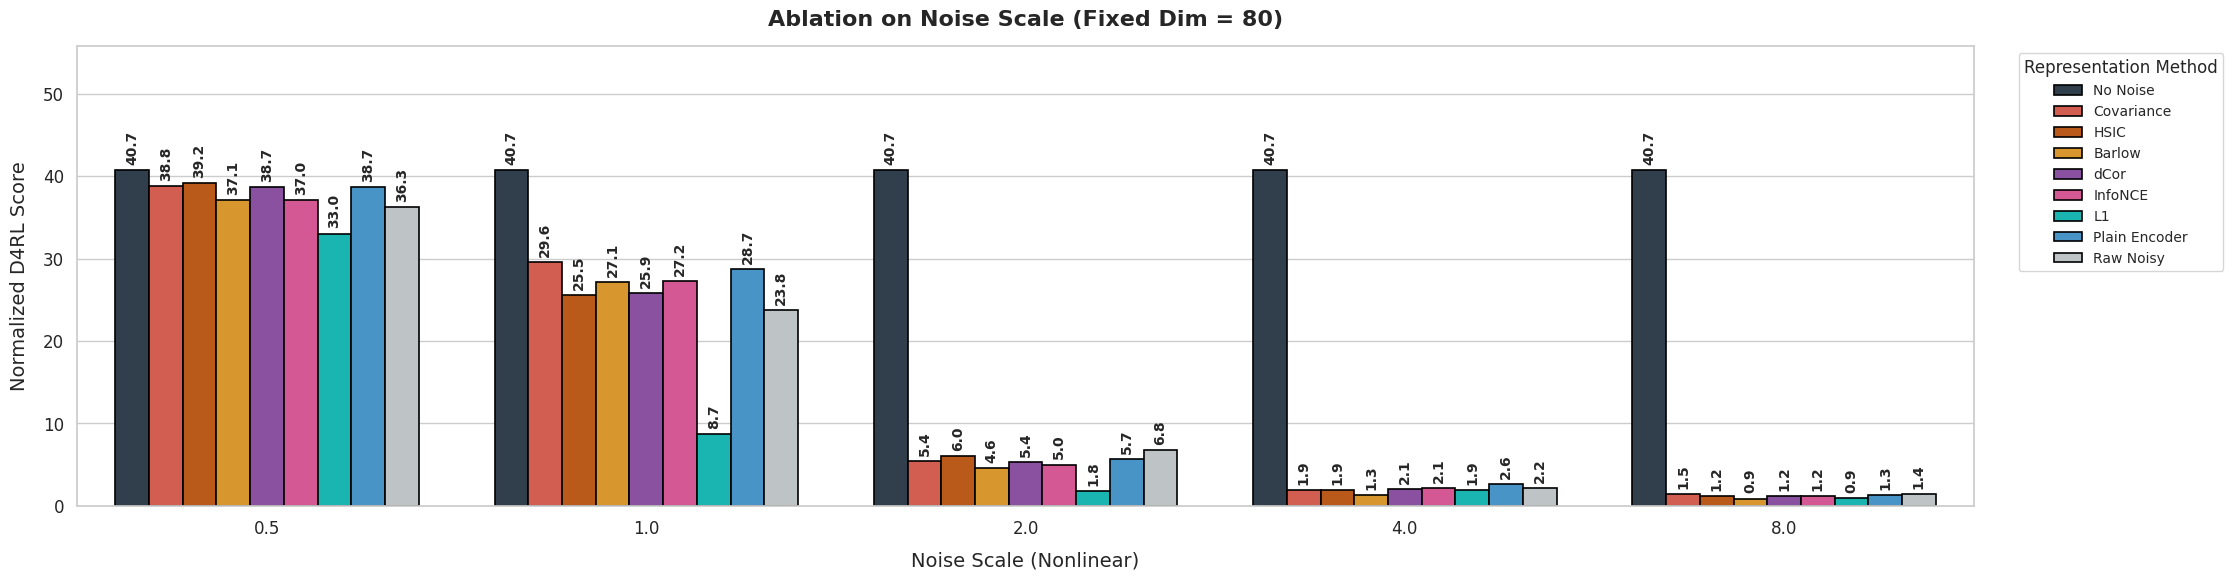

[INFO] Generating dimension-sweep charts for noise type 'nonlinear'...


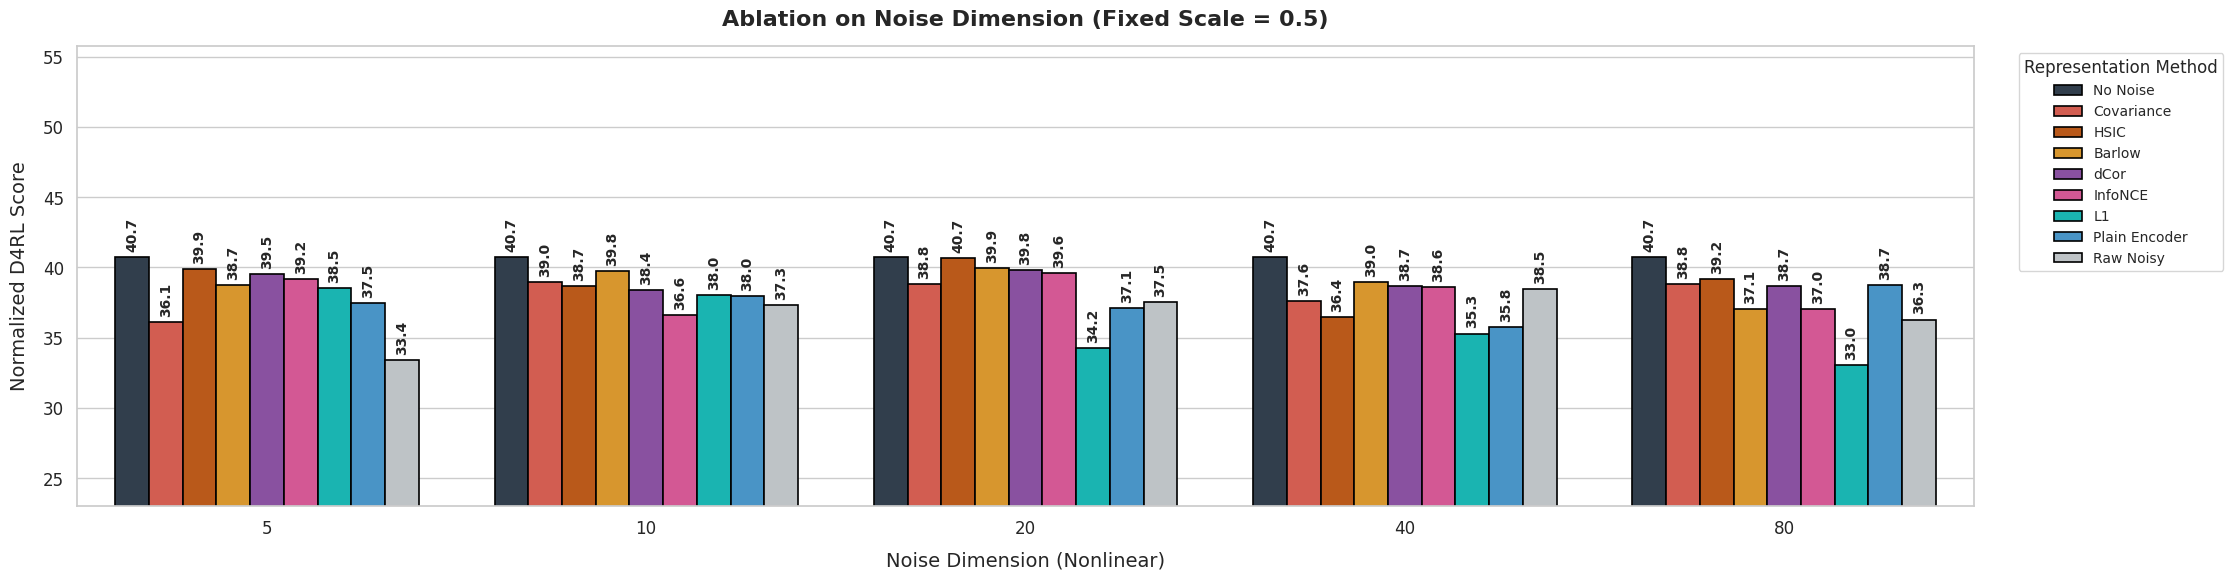

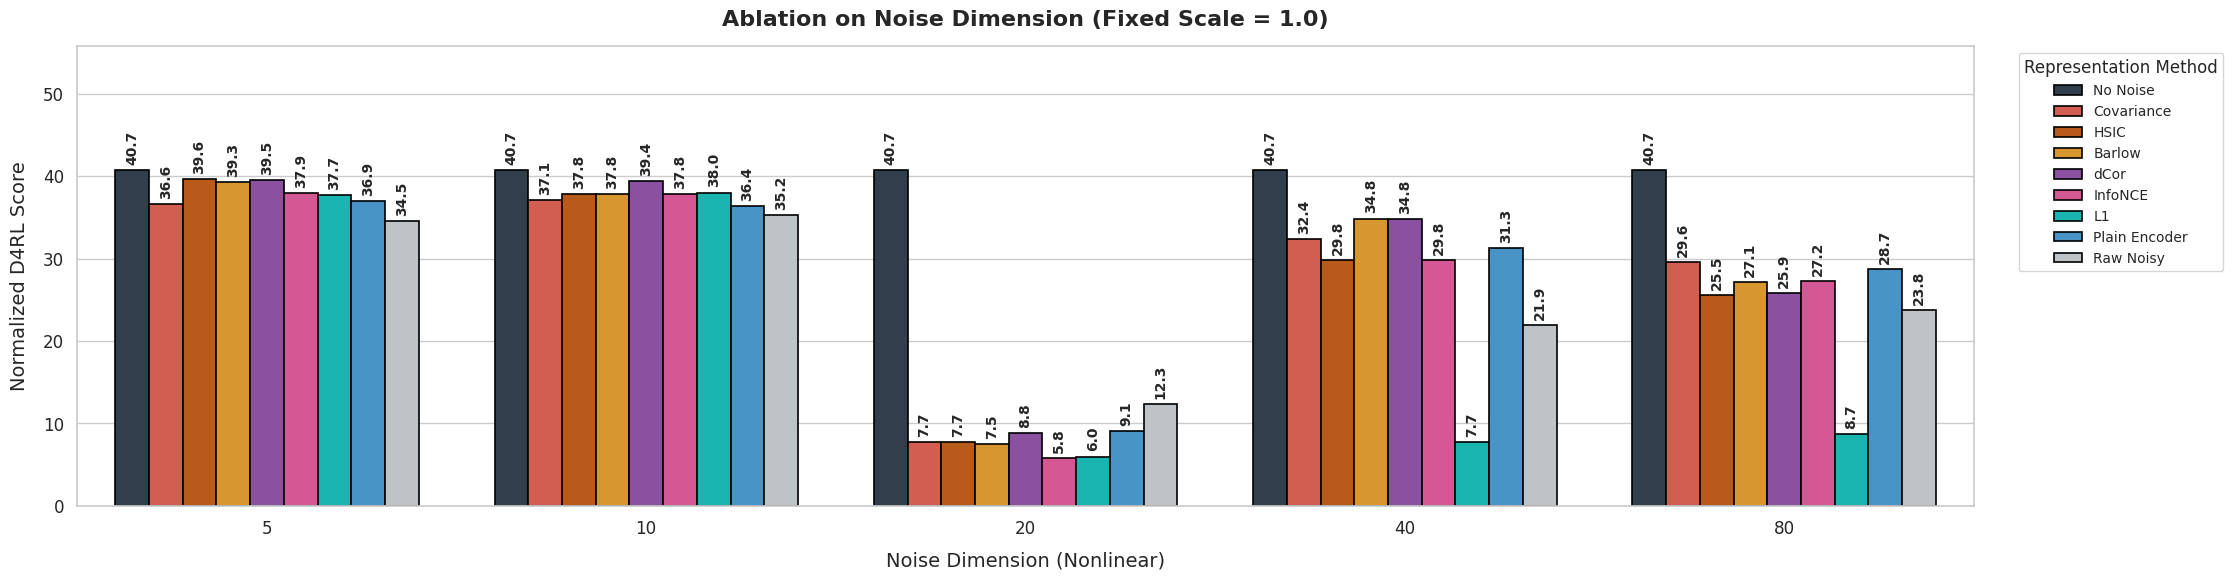

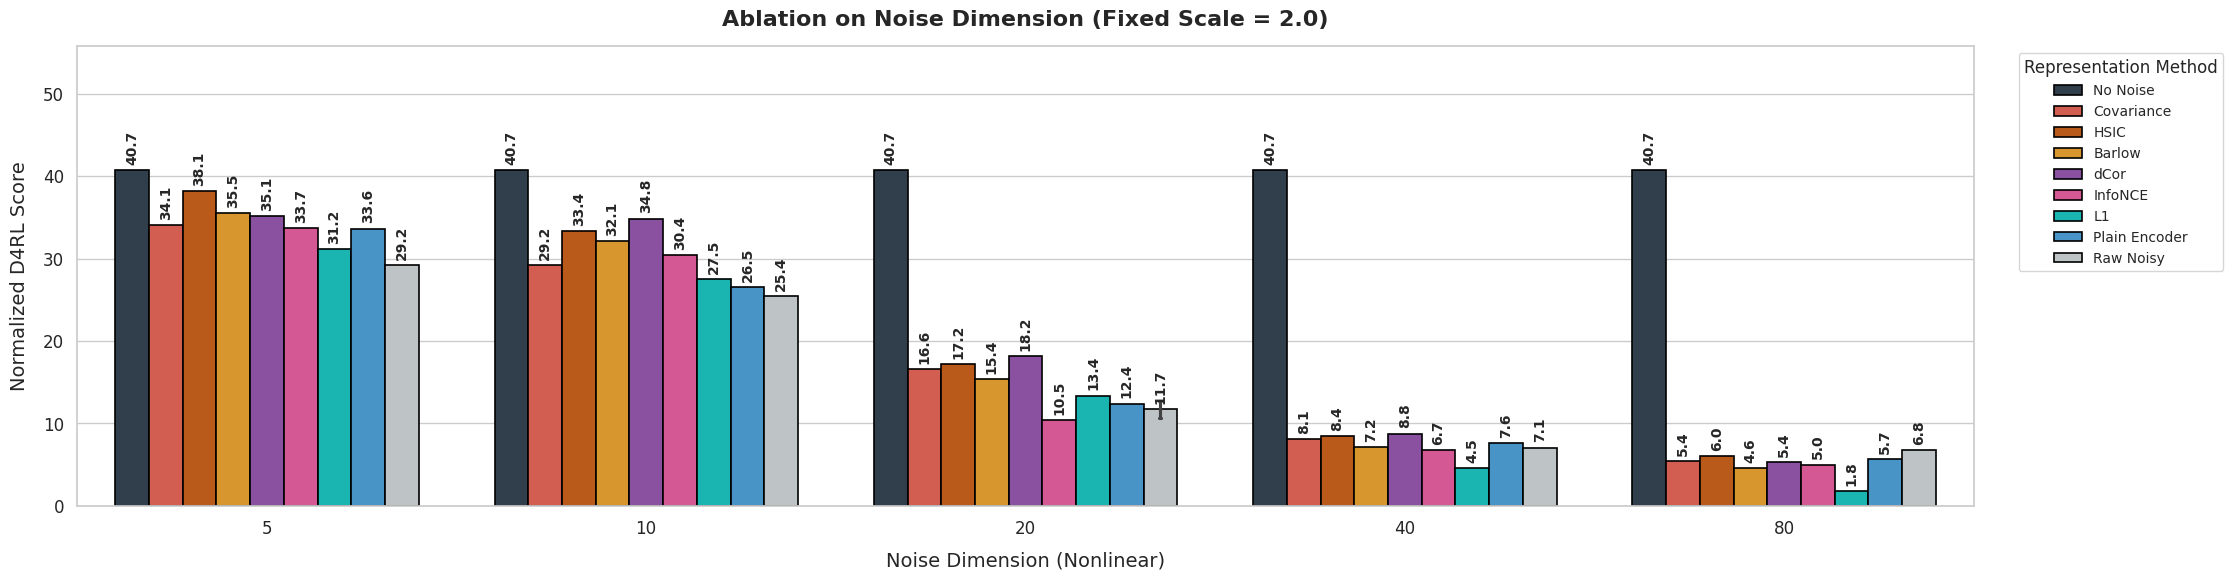

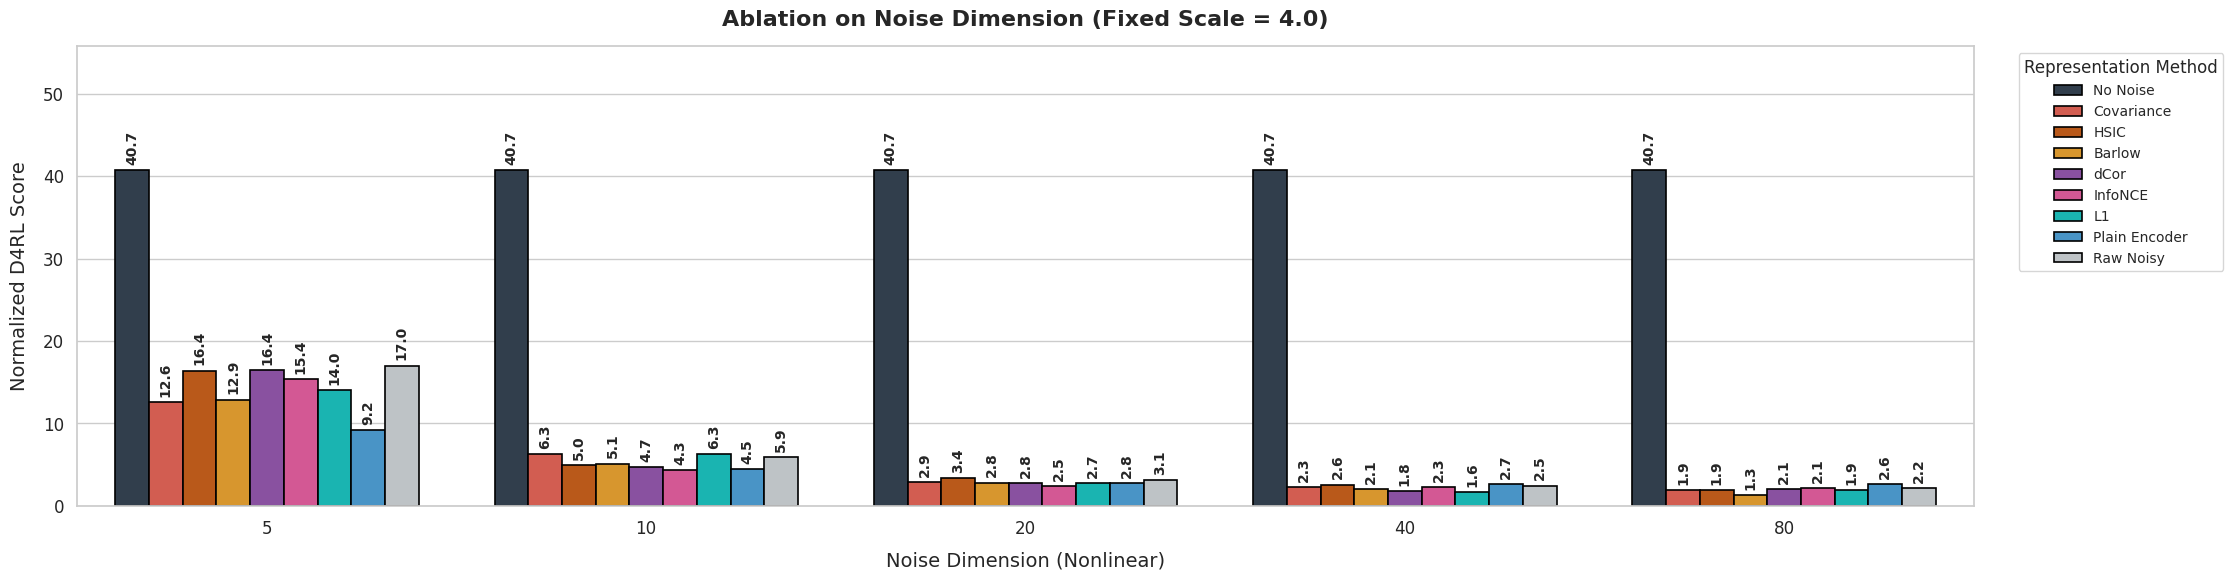

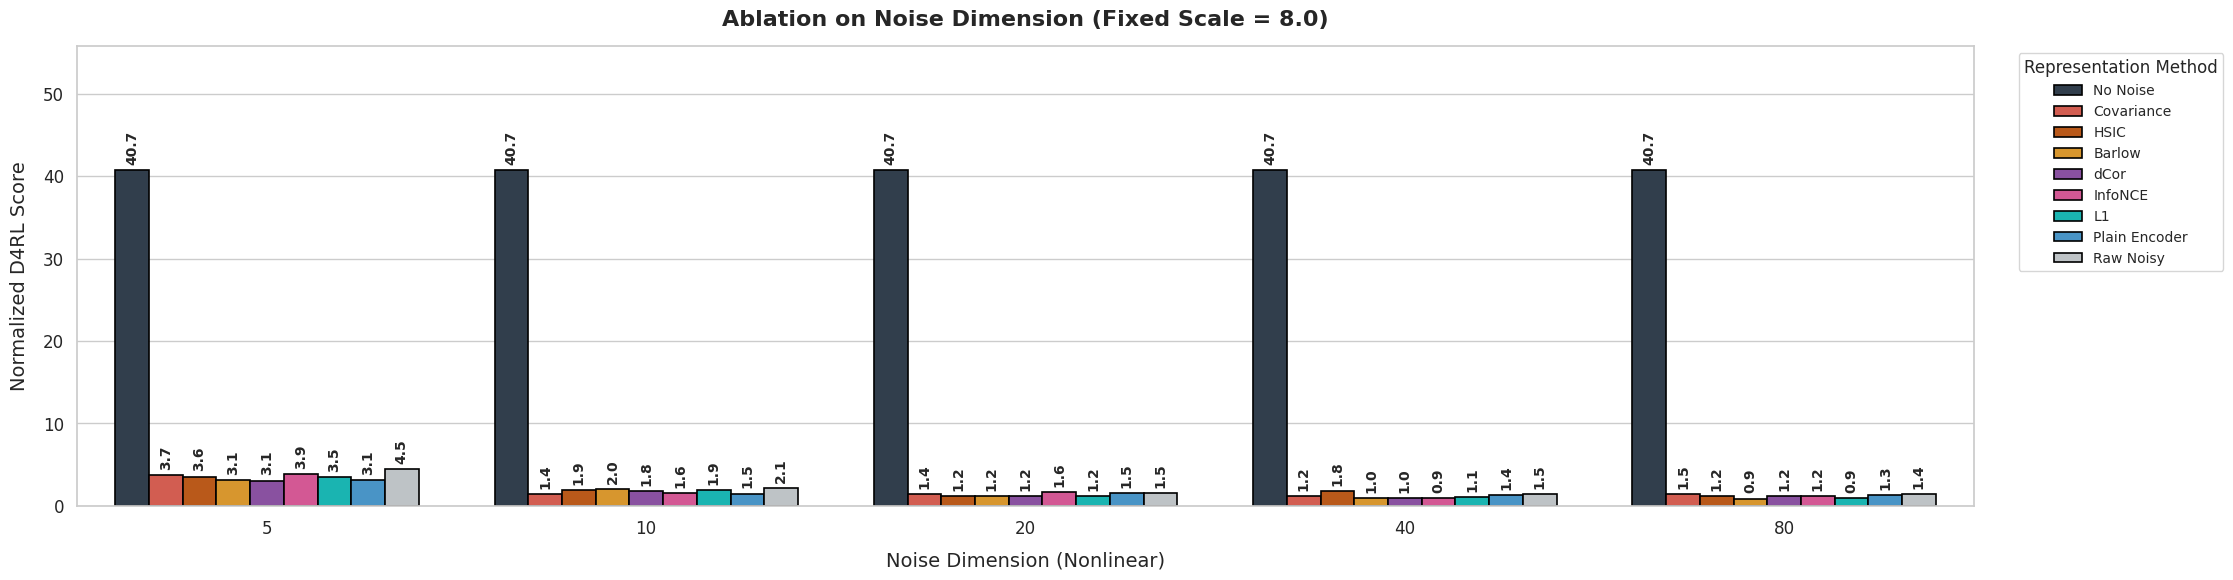

[INFO] Saved figure to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/ablations/nonlinear/scale_sweep_nonlinear_dim_5.png
[INFO] Saved figure to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/ablations/nonlinear/scale_sweep_nonlinear_dim_10.png
[INFO] Saved figure to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/ablations/nonlinear/scale_sweep_nonlinear_dim_20.png
[INFO] Saved figure to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/ablations/nonlinear/scale_sweep_nonlinear_dim_40.png
[INFO] Saved figure to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/ablations/nonlinear/scale_sweep_nonlinear_dim_80.png
[INFO] Saved figure to: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/ablations/nonlinear/dim_sweep_nonl

In [31]:
saved_figures = generate_ablation_charts(
    df_all=df_all,
    target_dims=TARGET_DIMS,
    target_scales=TARGET_SCALES,
    target_type_str=target_type_str,
    figure_out_dir=FIGURE_OUT_DIR,
    method_labels=method_labels,
    global_order=global_order,
    palette=palette,
    oracle_mean=oracle_mean,
    save_figures=SAVE_FIGURES,
    show_figures=SHOW_FIGURES,
)

for path in saved_figures:
    print(f"[INFO] Saved figure to: {path}")